ЛИНЕЙНАЯ РЕГРЕССИЯ

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Генерация данных

In [22]:
np.random.randn(42)

x = np.random.randn(1, 100)
a, b = 2, 1
eps = .1 * np.random.randn(1, 100)
y = b + a*x + eps

x.shape, y.shape

((1, 100), (1, 100))

Перемешиваем и разделим примеры на тестовые и обучающие

In [23]:
new_ind = np.arange(100)

np.random.shuffle(new_ind) # случайно перемешали их
new_ind

array([30, 45, 90, 24, 86, 28, 75, 78, 35, 87, 65, 27, 23, 13, 66,  0, 17,
       91, 48, 97, 76, 39, 61, 64,  9, 56, 67, 95, 57, 70, 68, 83, 84, 43,
       34, 72, 98, 85, 93, 29, 19, 96,  3, 63, 44, 42, 59, 40, 53, 49, 10,
       62, 82,  2, 25, 81, 15, 60, 55, 51, 79, 21, 16,  7, 88, 14, 99, 32,
       26, 41, 47, 54,  8, 37, 22, 94, 12, 80, 36, 31, 73, 50, 38,  5, 18,
       20, 58, 77, 11,  1,  6, 46,  4, 69, 92, 52, 74, 89, 71, 33])

In [24]:
train_ind = new_ind[:70] # обучающие
test_ind = new_ind[70:] # тестовые
# с помощью интексов разделим массивы на обучающие и тестовые
x_train, y_train = x[0][train_ind], y[0][train_ind]
x_test, y_test = x[0][test_ind], y[0][test_ind]

Рисуем график

In [25]:
def plot_line_or_scatter(type_plot, x_data, y_data, x_lable='', y_lable='', titlie='', color = 'r', yscale_log=False):
    _, ax = plt.subplots()

    if type_plot == 'scatter':
        ax.scatter(x_data, y_data, s = 10, color = color, alpha=0.75)

    else:
        ax.plot(x_data, y_data, lw = 2, color = color, alpha = 1)

    ax.set_title(titlie)
    ax.set_xlabel(x_lable)
    ax.set_ylabel(y_lable)

Рисуем обучающие данные

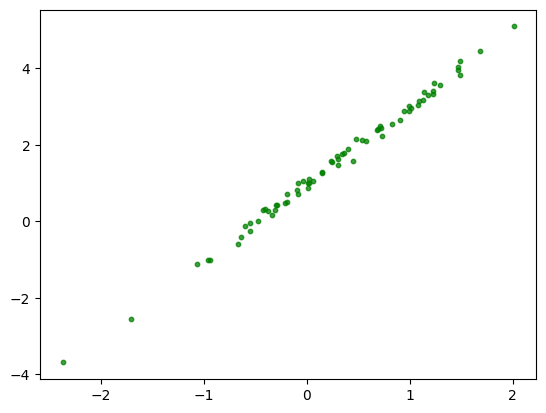

In [26]:
plot_line_or_scatter('scatter', x_train, y_train, color='green')

Создаем случайные числа 

In [27]:
a = np.random.rand(1)
b = np.random.rand(1)
a, b

(array([0.96526714]), array([0.96550442]))

Обучение методом наименьших квадраов

In [28]:
lr = 1e-3 # шаг обучение
epochs = 990 # количество эпох

Цикл обучения

In [29]:
Loss=[] # массив для значений функции ошибки
for ep in range(epochs):
    y_pred = b + a*x_train # считаем выход модели для всех примеров входов с текущими значениями параметров модели
    error = (y_pred - y_train) #считаем разницу между выходом и тем, который должени был быть

    loss = (error**2).mean() # считаем суммарную ошибку 
    Loss.append(loss) # добавляем текущее значение в массив
    b_grad = 2 * error.mean() # считаем производную по параметру, смещению на b (на 2 можно не умножать включив его в lr)
    a_grad = 2 * (x_train * error).mean() # считаем производную по параметру, множителю a

    # обучение - изменение параметров
    a = a - lr*a_grad
    b = b - lr*b_grad

    if ep % 20 == 0 or ep==epochs-1: # каждые 20 эпох будем
        print('ep: %3d loss: %8.6f a=%4.3f b=%4.3f'%(ep,loss,a,b)) # печатаем значения функции ошибки

ep:   0 loss: 0.846294 a=0.967 b=0.966
ep:  20 loss: 0.790310 a=0.998 b=0.978
ep:  40 loss: 0.738559 a=1.028 b=0.990
ep:  60 loss: 0.690691 a=1.057 b=1.001
ep:  80 loss: 0.646389 a=1.085 b=1.011
ep: 100 loss: 0.605363 a=1.112 b=1.020
ep: 120 loss: 0.567347 a=1.138 b=1.028
ep: 140 loss: 0.532098 a=1.163 b=1.036
ep: 160 loss: 0.499394 a=1.188 b=1.043
ep: 180 loss: 0.469032 a=1.212 b=1.050
ep: 200 loss: 0.440827 a=1.234 b=1.056
ep: 220 loss: 0.414607 a=1.257 b=1.062
ep: 240 loss: 0.390219 a=1.278 b=1.067
ep: 260 loss: 0.367518 a=1.299 b=1.072
ep: 280 loss: 0.346374 a=1.319 b=1.077
ep: 300 loss: 0.326668 a=1.338 b=1.081
ep: 320 loss: 0.308290 a=1.357 b=1.084
ep: 340 loss: 0.291138 a=1.375 b=1.087
ep: 360 loss: 0.275122 a=1.393 b=1.090
ep: 380 loss: 0.260155 a=1.410 b=1.093
ep: 400 loss: 0.246159 a=1.427 b=1.095
ep: 420 loss: 0.233065 a=1.443 b=1.097
ep: 440 loss: 0.220804 a=1.458 b=1.099
ep: 460 loss: 0.209318 a=1.473 b=1.100
ep: 480 loss: 0.198550 a=1.488 b=1.102
ep: 500 loss: 0.188449 a=

C:\Users\User\AppData\Local\Temp\ipykernel_18464\2164801136.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('ep: %3d loss: %8.6f a=%4.3f b=%4.3f'%(ep,loss,a,b)) # печатаем значения функции ошибки


Визуализация функции ошибки

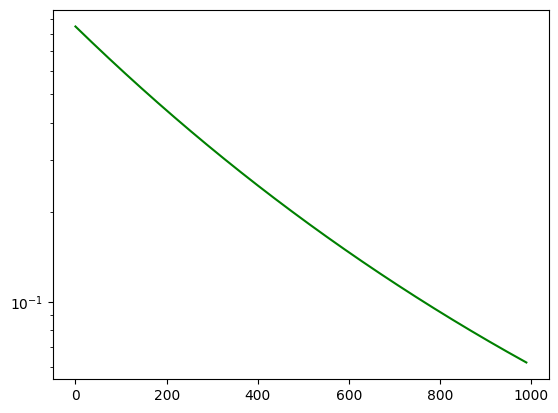

In [30]:
plt.plot(np.arange(epochs), Loss, color='green')
plt.yscale('log') # логарифмический масштаб для наглядности

Работа на тесте

In [31]:
y_test_pred = b + a*x_test

Вывод тестовых данных и реальных

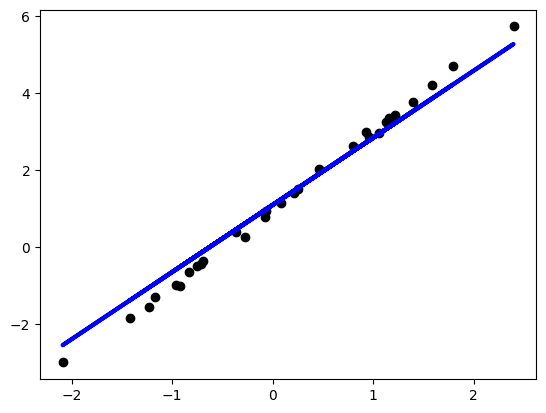

In [32]:
plt.scatter(x_test, y_test, color='black')
plt.plot(x_test, y_test_pred, color='blue', linewidth=3)
plt.show()

Библиотека SKLEARN

Обученные параметры: b=0.9750 a=2.0167


C:\Users\User\AppData\Local\Temp\ipykernel_18464\1099984853.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Обученные параметры: b=%6.4f a=%6.4f'%(linr.intercept_, linr.coef_)) #


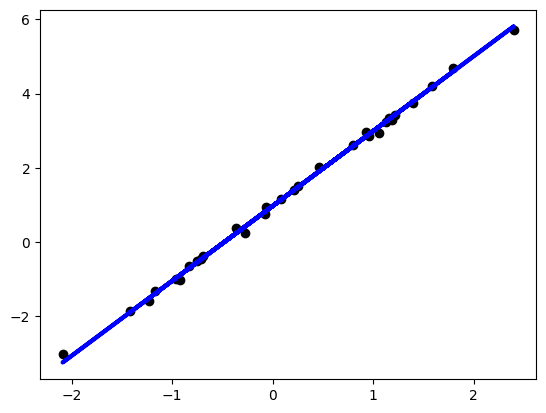

In [33]:
from sklearn.linear_model import LinearRegression # подключим модель линейной регрессии
linr = LinearRegression() # создадим ее
linr.fit(x_train.reshape(70, 1), y_train.reshape(70, 1)) # обучим модель, принудительно переформатировав размеры массивов
#linr.fit(x_train, y_train) # обучим модель, принудительно переформатировав размеры массивов
print('Обученные параметры: b=%6.4f a=%6.4f'%(linr.intercept_, linr.coef_)) #

y_test_pred=linr.predict(x_test.reshape(30,1))# посчитаем выход модели на тестовых примерах
plt.plot(x_test, y_test_pred, color='blue', linewidth=3)# нарисуем его
plt.scatter(x_test, y_test,  color='black') # и желаемый
plt.show()

Загружаем набор данных

In [34]:
from sklearn.datasets import load_wine

data_wine = load_wine()
data_wine.target[[1,80,100]]

array([0, 1, 1])

In [35]:
list(data_wine.target_names)

[np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

In [36]:
X = data_wine.data # в поле data - примеры входов, вектора
y = data_wine.target # Указания учителя = номера классов

from sklearn.model_selection import train_test_split # подключаем функцию для разделения данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # и отдаем 30% на тест, остальное на обучение
#y_train # убедитесь что и в обучении и в тесте есть данные разных классов
y_test #

array([1, 0, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 2, 1, 2, 2, 2, 2, 0, 0, 1,
       0, 1, 2, 1, 0, 1, 1, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 2, 1,
       2, 1, 0, 1, 1, 2, 1, 1, 0, 0])

Посмотрим первые 3 элемента

In [37]:
X_train[:3]

array([[1.311e+01, 1.900e+00, 2.750e+00, 2.550e+01, 1.160e+02, 2.200e+00,
        1.280e+00, 2.600e-01, 1.560e+00, 7.100e+00, 6.100e-01, 1.330e+00,
        4.250e+02],
       [1.388e+01, 1.890e+00, 2.590e+00, 1.500e+01, 1.010e+02, 3.250e+00,
        3.560e+00, 1.700e-01, 1.700e+00, 5.430e+00, 8.800e-01, 3.560e+00,
        1.095e+03],
       [1.340e+01, 3.910e+00, 2.480e+00, 2.300e+01, 1.020e+02, 1.800e+00,
        7.500e-01, 4.300e-01, 1.410e+00, 7.300e+00, 7.000e-01, 1.560e+00,
        7.500e+02]])

Модель линейной регрессии

In [38]:
lin_clf = LinearRegression() # создаем модель линейной регресии
lin_clf.fit(X_train, y_train) # обучаем ее
print(f'Обученные параметры: \nСмещение b={lin_clf.intercept_:6.4f} ')
print('Множители a= ',lin_clf.coef_)

Обученные параметры: 
Смещение b=3.8278 
Множители a=  [-0.13593489  0.02455445 -0.23062681  0.03937697 -0.0006464   0.15380848
 -0.34200945 -0.17767787  0.02862387  0.08618992 -0.25108527 -0.25438759
 -0.00069943]


Предсказание

0.8684953460256222


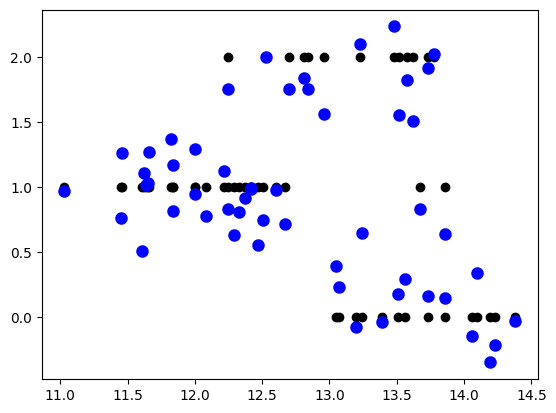

In [39]:
y_predicted = lin_clf.predict(X_test) # рассчитываем выходы модели на тестовых данных
score=lin_clf.score(X_test,y_test)# считаем ошибку
print(score)#
i=0 # номер измерения для построения
plt.scatter(X_test[:,i], y_test,  color='black')# строим желаемые выходы
plt.scatter(X_test[:,i], y_predicted, color='blue', linewidth=3)# и рассчитанные

Округлим выходы до ближайшего целого

In [40]:
y_pred_class=np.rint(y_predicted)
y_pred_class[y_pred_class>2]=2
y_pred_class[y_pred_class<0]=0
y_pred_class=y_pred_class.astype('int')
score=np.sum(y_pred_class==y_test)/len(y_test)
score

np.float64(0.9814814814814815)

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

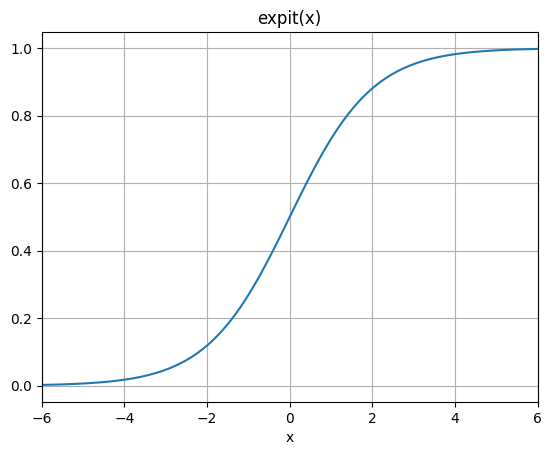

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit # подключаем функцию из библиотеки
x = np.linspace(-6, 6, 121) # диапазон по х
y = expit(x) # значение функции по у
plt.plot(x, y) #
plt.grid() #
plt.xlim(-6, 6)#
plt.xlabel('x')#
plt.title('expit(x)')#
plt.show()#


Создадим модель логистической регрессии

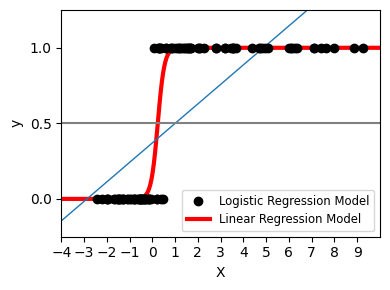

In [42]:
# import numpy as np #
import matplotlib.pyplot as plt #

from sklearn import linear_model #
from scipy.special import expit # функция для сигмоиды

# создадим данные: два отрезка на уровне 0 и 1

n_samples = 100 # число примеров
np.random.seed(0) # инициализация генератора случайных чисел
X = 1*np.random.normal(size=n_samples) # случаные числа по х, с нормальным законом распределения
y = (X > 0).astype(float) # класс 1 если больше нуля, 0 иначе, преобразуем в тип float
X[X > 0] *= 4 # умножим примеры входов из класса 1 на 4
X += .3 * np.random.normal(size=n_samples) # добавим ко всем примерам входа шум - случаные числа не очень большого разброса

X = X[:, np.newaxis] # сделаем столбец, добавив новое измерение к массиву, был одномерный станет двумерный. Можно было бы использовать reshape как раньше

# Обучение классификатора
log_reg = linear_model.LogisticRegression(C=1e5, max_iter=200) # создаем логистическую регрессию, C ставим побольше, это значит регуляризация будет влиять мало на результат
log_reg.fit(X, y) # обучаем модель, мы не стали разделять на обучающие и тестовые данные сейчас.

# рисуем результат
plt.figure(1, figsize=(4, 3)) #
plt.clf() #
plt.scatter(X.ravel(), y, color='black', zorder=20) # ravel() вытягивает массив, превращая его в одномерный

X_test = np.linspace(-5, 10, 300) # вот теперь создадим тестовые примеры входов

# посчитаем выход модели
loss = expit(X_test * log_reg.coef_ + log_reg.intercept_).ravel() # вручную
loss1 = log_reg.predict_proba(X_test[:, np.newaxis])[:,1].ravel() # через predict_proba, берем второй столбец (индекс 1) , чтобы сам выход вернуть
plt.plot(X_test, loss1, color='red', linewidth=3) #

# сравним с линейной регрессией
ols = linear_model.LinearRegression() # линейная регрессия
ols.fit(X, y) # обучаем ее
plt.plot(X_test, ols.coef_ * X_test + ols.intercept_, linewidth=1)

# рисуем
plt.axhline(.5, color='.5') #

plt.ylabel('y') #
plt.xlabel('X') #
plt.xticks(range(-5, 10)) #
plt.yticks([0, 0.5, 1]) #
plt.ylim(-.25, 1.25) #
plt.xlim(-4, 10) #
plt.legend(('Logistic Regression Model', 'Linear Regression Model'), #
           loc="lower right", fontsize='small') #
plt.tight_layout() #
plt.show() #

Обученные параметры b=[-0.00616075] a=[[0.02222096 0.02578357]]


(-40.0, 40.0)

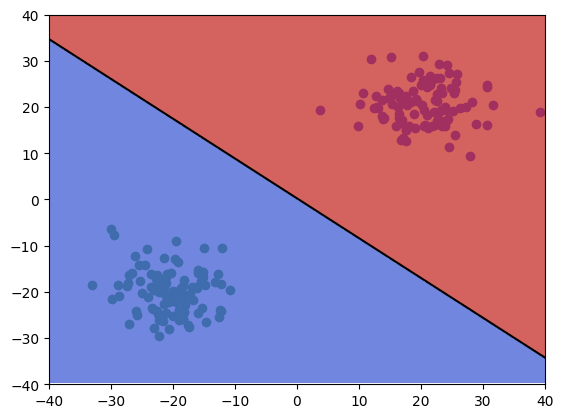

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model #

np.random.seed(42) # начало генератора случайных чисел, чтобы после перезапуска были одинаковые
N=100 # число точек в одном классе

# первый класс, случайные точки вокруг (-20, -20) выход = -1
x1 = -20+5*np.random.randn(N, 1) #
y1 = -20+5*np.random.randn(N, 1) #
z1=-1*np.ones((100,1)) #
# второй класс, случайные точки вокруг (+20, +20) выход = +1
x2 = 20+5*np.random.randn(N, 1) #
y2 = 20+5*np.random.randn(N, 1) #
z2=+1*np.ones((100,1)) #

# большой выброс, раскомментируйте для теста
#x1[0]=+1000
#y1[0]=+1000

# Объединяем массивы в один
Input=np.hstack((np.vstack((x1, x2)),np.vstack((y1 , y2))))
Output=np.vstack((z1,z2))
#print(Input.shape)
#print(Output.shape)

fig, ax = plt.subplots()

# рисуем обучающие точки своим цветом
ax.scatter(Input[0:N-1,0],Input[0:N-1,1],color='green')
ax.scatter(Input[N:,0],Input[N:,1],color='blue')

# создаем и обучаем линейную регрессию
linr = linear_model.LinearRegression() # создадим ее. normalize=False если хотим без нормализации
linr.fit(Input, Output) # обучим модель, принудительно переформатировав размеры массивов
print('Обученные параметры b={d[0]} a={d[1]}'.format(d=(linr.intercept_, linr.coef_))) #

out_pred=linr.predict(Input)# посчитаем выход модели

# Если выход меньше нуля - принимаем за первый класс, если больше - за второй
# найдем ошибки, т.е. не совпадение между истинными классами и полученными моделью
err1=(out_pred>0) & (Output==-1)# думаем что второй, а на самом деле первый класс
err2=(out_pred<0) & (Output==+1)# думаем что первый, а на самом деле второй класс
err1=err1[:,0]
err2=err2[:,0]

# нарисуем ошибки
ax.scatter(Input[err1,0],Input[err1,1],color='yellow',marker='x')
ax.scatter(Input[err2,0],Input[err2,1],color='magenta',marker='x')

# возьмем много точек плоскости
h=0.2
x_min,y_min=Input.min(axis=0)-10
x_max, y_max=Input.max(axis=0)+10
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # точки плоскости из равномерной сетки
Input_test=np.c_[xx.ravel(), yy.ravel()]
#print(Input.shape)

# посчитаем для них выходы обученной линейной регрессии
zz = linr.predict(Input_test)
zz = zz.reshape(xx.shape)
zz[zz>0]=1 # больше нуля - второй класс
zz[zz<0]=-1 # меньше нуля - первый класс
ax.contourf(xx, yy, zz, cmap=plt.cm.coolwarm, alpha=0.8); # рисуем цветом выходы для всех точек плоскости

# рисуем прямую
xxx=np.arange(x_min,x_max,h)
yyy=-(linr.intercept_[0] + linr.coef_[0][0]*xxx)/linr.coef_[0][1] # x2=-(a1*x1+b)/a2

ax.plot(xxx,yyy,color='black');
ax.set_xlim([-40, 40])
ax.set_ylim([-40, 40])

Обученные параметры b=[-0.00030136] a=[[0.25898092 0.27060934]]


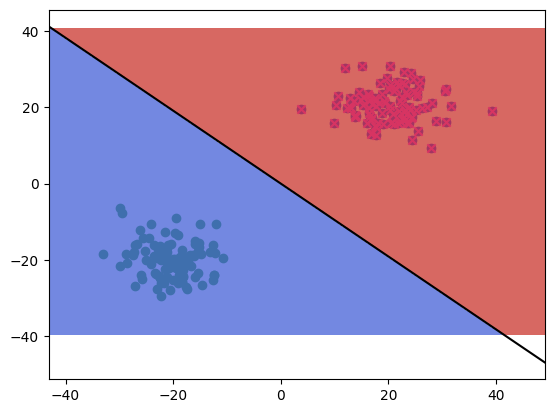

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model #

np.random.seed(42) # начало генератора случайных чисел, чтобы после перезапуска были одинаковые
N=100

x1 = -20+5*np.random.randn(N, 1) #
y1 = -20+5*np.random.randn(N, 1) #
z1=0*np.ones((100,1)) # классы должны быть 0 или 1

x2 = 20+5*np.random.randn(N, 1) #
y2 = 20+5*np.random.randn(N, 1) #
z2=1*np.ones((100,1)) # классы должны быть 0 или 1

Input=np.hstack((np.vstack((x1, x2)),np.vstack((y1 , y2))))
Output=np.vstack((z1,z2))
#print(Input.shape)
#print(Output.shape)

fig, ax = plt.subplots()

ax.scatter(Input[0:N-1,0],Input[0:N-1,1],color='green')
ax.scatter(Input[N:,0],Input[N:,1],color='blue')

logr = linear_model.LogisticRegression() #
logr.fit(Input, Output.ravel()) # обучим модель,
print('Обученные параметры b={d[0]} a={d[1]}'.format(d=(logr.intercept_, logr.coef_))) #
out_pred=logr.predict(Input)# посчитаем выход модели
out_pred

# в логистической регресии predict возвращает классы, так что не надо самим относить выходы к классам
# больше 0.5 класс 1, меньше 0.5 класс 0.
err1=(out_pred==1) & (Output==0)
err2=(out_pred==0) & (Output==1)
err1=err1[:,0]
err2=err2[:,0]

ax.scatter(Input[err1,0],Input[err1,1],color='yellow',marker='x')
ax.scatter(Input[err2,0],Input[err2,1],color='magenta',marker='x')

h=0.2
x_min,y_min=Input.min(axis=0)-10
x_max, y_max=Input.max(axis=0)+10
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Input_test=np.c_[xx.ravel(), yy.ravel()]
#print(Input.shape)

zz = logr.predict(Input_test)
zz = zz.reshape(xx.shape)
# в логистической регресии predict возвращает классы, так что не надо самим относить выходы к классам
#zz[zz>0]=1
#zz[zz<0]=-1
ax.contourf(xx, yy, zz, cmap=plt.cm.coolwarm, alpha=0.8);

xxx=np.arange(x_min,x_max,h)
# все равно это прямая линия, но возможно с другими коэффициентами
yyy=-(logr.intercept_[0] + logr.coef_[0][0]*xxx)/logr.coef_[0][1]

ax.plot(xxx,yyy,color='black');

ДОМАШНЕЕ ЗАДАНИЕ

Импортируем библиотеки

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


Загружаем данные и проводим первичный анализ

In [46]:
DATA_PATH = "data.csv"

df = pd.read_csv(DATA_PATH)


Первые строки

In [47]:
df.head()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


Информация о датасете

In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

Описательные статистики

In [49]:
df.describe()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


Распределение таргета

In [50]:
df["default"].value_counts()
df["default"].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

Проверка корректности значений

In [51]:
assert df["debt_to_income"].between(0, 1).all()
assert df["region_risk_score"].between(0, 1).all()
assert df["default"].isin([0, 1]).all()


Краткие выводы:
датасет состоит из 3000 наблюдений
является умеренно несбалансируемым

Подготовим признаки и таргет

In [52]:
X = df.drop(columns=["client_id", "default"])
y = df["default"]


Применяем StandartScaler

Разделяем на train/test

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Бейзлайн-модель

In [54]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_proba_dummy)

print("Dummy Accuracy:", dummy_accuracy)
print("Dummy ROC-AUC:", dummy_roc_auc)


Dummy Accuracy: 0.59
Dummy ROC-AUC: 0.5


Логистическая регрессия и Pipeline

In [55]:
C_values = [0.01, 0.1, 1.0, 10.0]
results = []

for C in C_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df


,C,accuracy,roc_auc
0,0.01,0.806667,0.875442
1,0.10,0.801667,0.875477
2,1.00,0.800000,0.875614
3,10.00,0.800000,0.875637


Обучение лучшей модели

In [56]:
best_C = results_df.sort_values("roc_auc", ascending=False).iloc[0]["C"]

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=best_C, max_iter=1000, random_state=42))
])

best_model.fit(X_train, y_train)

y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]


Метрики качества

In [57]:
print("LogReg Accuracy:", accuracy_score(y_test, y_pred_lr))
print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
confusion_matrix(y_test, y_pred_lr)
print(classification_report(y_test, y_pred_lr))


LogReg Accuracy: 0.8
LogReg ROC-AUC: 0.8756373156951908
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       354
           1       0.79      0.69      0.74       246

    accuracy                           0.80       600
   macro avg       0.80      0.78      0.79       600
weighted avg       0.80      0.80      0.80       600



ROC-кривая и сохранение графика

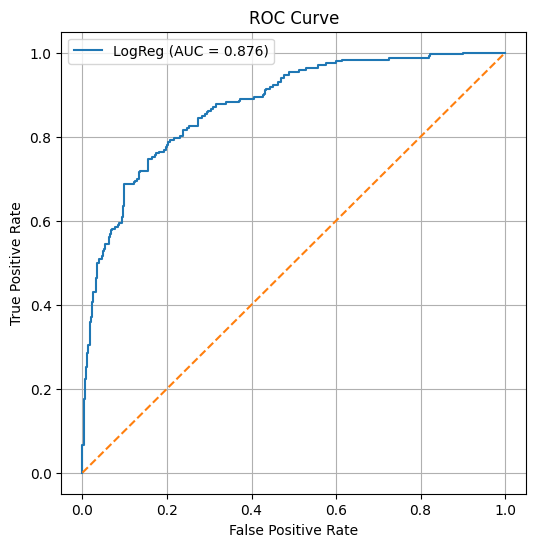

In [58]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.savefig("figures/roc_curve.png")
plt.show()


Сравнение моделей

In [59]:
comparison = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [dummy_accuracy, accuracy_score(y_test, y_pred_lr)],
    "ROC-AUC": [dummy_roc_auc, roc_auc_score(y_test, y_proba_lr)]
})

comparison


,Model,Accuracy,ROC-AUC
0,DummyClassifier,0.59,0.500000
1,LogisticRegression,0.80,0.875637


Выводы:
Бейзлайн-модель DummyClassifier демонстрирует низкое качество, так как игнорирует признаки и предсказывает наиболее частый класс.
Логистическая регрессия существенно превосходит бейзлайн по метрике ROC-AUC, что говорит о способности модели эффективно различать дефолтных и недефолтных клиентов.
Подбор параметра регуляризации C показал, что умеренная регуляризация обеспечивает наилучший баланс между смещением и дисперсией.
Логистическая регрессия является интерпретируемой и разумной моделью для данной задачи кредитного скоринга.